# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [173]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [174]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')  

In [175]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [176]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [177]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [178]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape) 

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [179]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [180]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [181]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [182]:

# cantidad de nulos para users
print(usage.isnull().sum())
print(usage.isnull().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


In [183]:
print(usage.isnull().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
La columna duración y amplitud tienen valores faltantes pero en una proporción muy pequeña en comparación con todo el resto de los datos
- Indica qué harías: ¿imputar, eliminar, ignorar?
Imputaría esos datos faltantes para que no afecten los demás datos. 


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [184]:


# análisis de columnas numéricas para detectar posibles sentinels

for col in users.select_dtypes(include='number').columns:

    print(f'\n--- Columna: {col} ---')

    # resumen estadístico
    print(users[col].describe())

    # valores mínimos y máximos
    print('Valor mínimo:', users[col].min())
    print('Valor máximo:', users[col].max())

    # búsqueda de sentinels comunes
    print('Cantidad de -1:', (users[col] == -1).sum())
    print('Cantidad de 0:', (users[col] == 0).sum())
    print('Cantidad de 999:', (users[col] == 999).sum())

    # valores nulos
    print('Valores nulos:', users[col].isnull().sum())


--- Columna: user_id ---
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
Valor mínimo: 10000
Valor máximo: 13999
Cantidad de -1: 0
Cantidad de 0: 0
Cantidad de 999: 0
Valores nulos: 0

--- Columna: age ---
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64
Valor mínimo: -999
Valor máximo: 79
Cantidad de -1: 0
Cantidad de 0: 0
Cantidad de 999: 0
Valores nulos: 0



- La columna `user_id` es de tipo numérico, no tiene valores nulos o valores inválidos a considerar. 
- La columna `age` es de tipo numérico, no tiene valores nulos pero sí tiene valores valores inválidos como -999.
  


In [185]:
numeric_cols = usage.select_dtypes(include='number').columns

for col in numeric_cols:

    print(f'\n--- Columna: {col} ---')

    # resumen estadístico
    print(usage[col].describe())

    # valores mínimos y máximos

    print('Valor mínimo:', usage[col].min())
    print('Valor máximo:', usage[col].max())

    # búsqueda de sentinels comunes
    print('Cantidad de -1:', (usage[col] == -1).sum())
    print('Cantidad de 0:', (usage[col] == 0).sum())
    print('Cantidad de 999:', (usage[col] == 999).sum())

    # valores nulos
    print('Valores nulos:', usage[col].isnull().sum())



--- Columna: id ---
count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64
Valor mínimo: 1
Valor máximo: 40000
Cantidad de -1: 0
Cantidad de 0: 0
Cantidad de 999: 1
Valores nulos: 0

--- Columna: user_id ---
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64
Valor mínimo: 10000
Valor máximo: 13999
Cantidad de -1: 0
Cantidad de 0: 0
Cantidad de 999: 0
Valores nulos: 0

--- Columna: duration ---
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64
Valor mínimo: 0.0
Valor máximo: 120.0
Cantidad de -1: 0
Cantidad de 0: 15
Cantidad de 999: 0
Valores n

- Las columnas `id` y `user_id` no tienen valores nulos o valores inválidos. 
- Las columnas `duration` y `user_id` sí tienen valores nulos pero no inválidos. 

In [186]:

# análisis de columnas categóricas de users

categorical_cols = users.select_dtypes(include='object').columns

for col in categorical_cols:

    print(f'\n--- Columna: {col} ---')

    # cantidad de valores únicos
    print('Cantidad de valores únicos:')
    print(users[col].nunique())

    # valores únicos
    print('\nValores únicos:')
    print(users[col].unique())

    # frecuencia de valores
    print('\nFrecuencia de valores:')
    print(users[col].value_counts())

    # valores nulos
    print('\nValores nulos:')
    print(users[col].isnull().sum())


--- Columna: first_name ---
Cantidad de valores únicos:
6

Valores únicos:
['Carlos' 'Mateo' 'Sofia' 'Luis' 'Mariana' 'Ana']

Frecuencia de valores:
Mateo      685
Carlos     685
Ana        683
Mariana    661
Luis       645
Sofia      641
Name: first_name, dtype: int64

Valores nulos:
0

--- Columna: last_name ---
Cantidad de valores únicos:
5

Valores únicos:
['Garcia' 'Torres' 'Ramirez' 'Lopez' 'Gomez']

Frecuencia de valores:
Lopez      835
Garcia     815
Torres     794
Gomez      778
Ramirez    778
Name: last_name, dtype: int64

Valores nulos:
0

--- Columna: city ---
Cantidad de valores únicos:
7

Valores únicos:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Frecuencia de valores:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores nulos:
469

--- Columna: reg_date ---
Cantidad de valores únicos:
3961

Valores únicos:
['2022-01-01 00:00:00.000000000' '2022-01-01 06:34:17.91447

- La columna `city` tiene valores nulos y 96 valores inválidos marcados con un signo de interrogación. 
- La columna `plan`tiene valores nulos.
- La columna `churn_date`tiene valores nulos. 

In [187]:

categorical_cols = usage.select_dtypes(include='object').columns

for col in categorical_cols:

    print(f'\n--- Columna: {col} ---')

    # cantidad de valores únicos
    print('Cantidad de valores únicos:')
    print(usage[col].nunique())

    # valores únicos
    print('\nValores únicos:')
    print(usage[col].unique())

    # frecuencia de valores
    print('\nFrecuencia de valores:')
    print(usage[col].value_counts())

    # valores nulos
    print('\nValores nulos:')
    print(usage[col].isnull().sum())


--- Columna: type ---
Cantidad de valores únicos:
2

Valores únicos:
['call' 'text']

Frecuencia de valores:
text    22092
call    17908
Name: type, dtype: int64

Valores nulos:
0

--- Columna: date ---
Cantidad de valores únicos:
39950

Valores únicos:
['2024-01-01 00:00:00.000000000' '2024-01-01 00:06:30.969774244'
 '2024-01-01 00:13:01.939548488' ... '2024-06-29 23:46:58.060451510'
 '2024-06-29 23:53:29.030225754' '2024-06-30 00:00:00.000000000']

Frecuencia de valores:
2024-01-22 12:50:25.155628890    1
2024-01-21 05:27:14.890872271    1
2024-01-23 16:51:35.357383934    1
2024-05-11 09:10:16.425410634    1
2024-02-26 23:18:29.457736443    1
                                ..
2024-03-19 21:48:50.923273081    1
2024-04-25 17:30:51.976299406    1
2024-02-03 09:03:13.054826370    1
2024-04-15 16:31:30.047251180    1
2024-02-22 07:52:54.469361734    1
Name: date, Length: 39950, dtype: int64

Valores nulos:
50


- La columna `type`tiene valores nulos.
- La columna `date`tiene valores nulos. 




---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para 
cada caso. 


**Valores inválidos o sentinels**  

- En `usage`, la columna `id` tiene un valor `999`, pero no lo trataría como inválido porque parece ser un identificador válido dentro del rango 1 a 40000.
- En `duration` hay 15 valores en `0`. Puede ser válido si representa interacciones sin duración, pero conviene revisarlo.
- En `length` hay 133 valores en `0`. Puede ser válido si son llamadas/textos sin longitud registrada, pero debe analizarse según el contexto.
- En `users`, la columna `city` tiene 96 valores marcados como `?`, que sí parecen valores inválidos o desconocidos.
- En `users`, `churn_date` aparece con valores en formato extraño tipo `1,71832E+18`, por lo que necesita conversión a fecha.

**Valores nulos**

- `duration` tiene 22076 valores nulos.
- `length` tiene 17896 valores nulos.
- `city` tiene 469 valores nulos.
- `churn_date` tiene 3534 valores nulos, pero esto puede significar que el usuario no canceló el servicio.
- `date` tiene 50 valores nulos.

**Acción recomendada**

- Reemplazar `?` en `city` por `NaN`.
- Convertir `reg_date`, `date` y `churn_date` a formato fecha usando `pd.to_datetime()`.
- No eliminar automáticamente los nulos de `churn_date`, porque probablemente indican usuarios activos.
- Revisar si `duration = 0` y `length = 0` son datos válidos según el tipo de interacción.
- Para `duration`, `length` y `date`, decidir si imputar o eliminar dependiendo del análisis posterior.




### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [188]:

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')




In [189]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [190]:
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

In [191]:
# Años en reg_date
print("Años en reg_date:")
print(users['reg_date'].dt.year.value_counts().sort_index())


Años en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


Se revisaron los años presentes en las columnas de fecha. En users.reg_date se identificaron registros de 2022, 2023 y 2024, así como 40 registros correspondientes a 2026. Debido a que el conjunto de datos contiene información únicamente hasta 2024, estos registros de 2026 se consideran fechas fuera de rango y deben revisarse para determinar si corresponden a errores de captura.


In [192]:

# Años en date
print("\nAños en usage.date:")
print(usage['date'].dt.year.value_counts().sort_index())


Años en usage.date:
2024.0    39950
Name: date, dtype: int64



En usage.date todos los registros corresponden a 2024, por lo que no se detectaron inconsistencias. 


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

Diagnóstico: Se identificaron 40 registros en la columna reg_date con el año 2026. Dado que el conjunto de datos contiene información únicamente hasta 2024, estos registros se consideran fechas fuera de rango y probablemente corresponden a errores de captura o registro. En la columna usage.date no se detectaron inconsistencias, ya que todos los registros corresponden al año 2024.

Acción recomendada: Revisar los registros con fechas de 2026 para confirmar si se trata de errores de captura. Si no es posible verificar la fecha correcta con una fuente confiable, recomendaría marcarlos como valores faltantes (NaT) o excluirlos del análisis para evitar sesgos en los resultados. Las fechas válidas de 2022, 2023 y 2024 pueden conservarse sin modificaciones.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [193]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()



count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [194]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)



Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [195]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()



2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [196]:
# Verificación MAR en usage (Missing At Random) para duration

usage['duration_missing'] = usage['duration'].isna()

pd.crosstab(
    usage['duration_missing'],
    usage['type'],
    normalize='index'
)


type,call,text
duration_missing,,
False,0.999107,0.000893
True,0.000000,1.000000


In [197]:
# Verificación MAR en usage (Missing At Random) para length

usage['length_missing'] = usage['length'].isna()

pd.crosstab(
    usage['length_missing'],
    usage['type'],
    normalize='index'
)


type,call,text
length_missing,,
False,0.000543,0.999457
True,1.000000,0.000000


Diagnóstico: Los valores nulos en duration y length no parecen ser errores de captura. Al analizar la relación con la variable type, se observó que los registros de tipo text presentan valores nulos en duration, mientras que los registros de tipo call presentan valores nulos en length. Esto indica que los valores faltantes dependen del tipo de comunicación y responden a la naturaleza de los datos.

Conclusión: Los nulos son esperados y tienen una explicación lógica: los mensajes de texto no tienen duración y las llamadas no tienen longitud de mensaje. Por lo tanto, no se recomienda imputar estos valores, sino conservarlos como faltantes estructurales para evitar introducir información incorrecta en el análisis.




---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [198]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [199]:

# Renombrar columnas

usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [200]:

# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [201]:
# Resumen estadístico de las columnas numéricas
user_profile[['age',
              'cant_mensajes',
              'cant_llamadas',
              'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [202]:
# Distribución porcentual de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

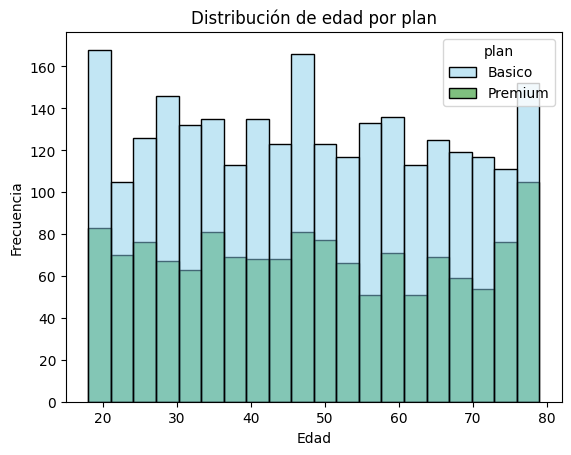

In [203]:

# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
La distribución de edades es relativamente uniforme entre los 18 y 80 años, sin concentraciones muy marcadas en un rango específico. Los usuarios de los planes Básico y Premium presentan distribuciones similares, por lo que no se observa una relación clara entre la edad y el tipo de plan. La distribución puede considerarse aproximadamente uniforme, sin un sesgo evidente.

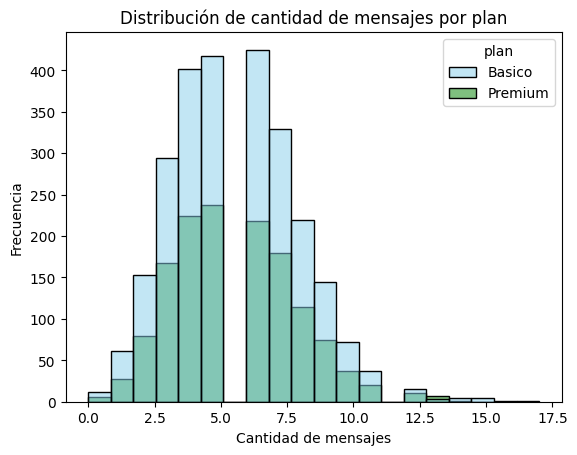

In [204]:

# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
La mayoría de los usuarios envía entre 3 y 8 mensajes. Se observa una ligera cola hacia la derecha debido a algunos usuarios con cantidades más altas de mensajes, por lo que la distribución presenta un sesgo positivo (a la derecha). No se aprecian diferencias importantes entre los planes Básico y Premium.

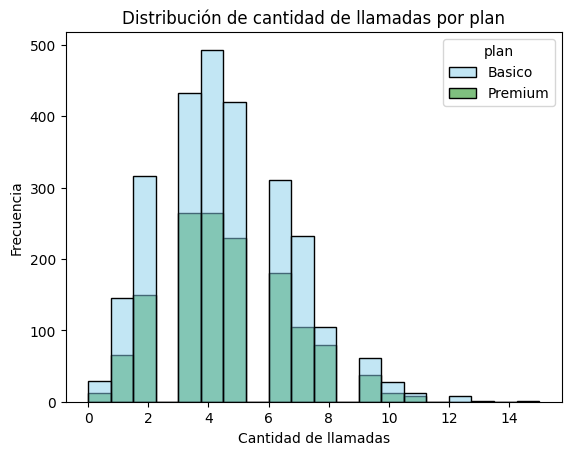

In [205]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
La mayor parte de los usuarios realiza entre 3 y 7 llamadas. Existen algunos usuarios con cantidades de llamadas considerablemente mayores, generando una cola hacia la derecha. La distribución presenta sesgo a la derecha y no se observan diferencias marcadas entre los tipos de plan.

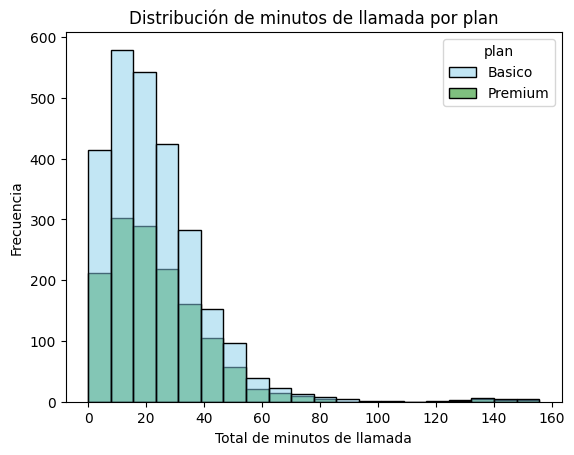

In [206]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Total de minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
La mayoría de los usuarios acumula pocos minutos de llamada, mientras que un grupo reducido presenta consumos mucho más altos. La distribución muestra un fuerte sesgo a la derecha y posibles valores atípicos en la parte superior. Los patrones observados son similares para ambos planes, sin diferencias visuales significativas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

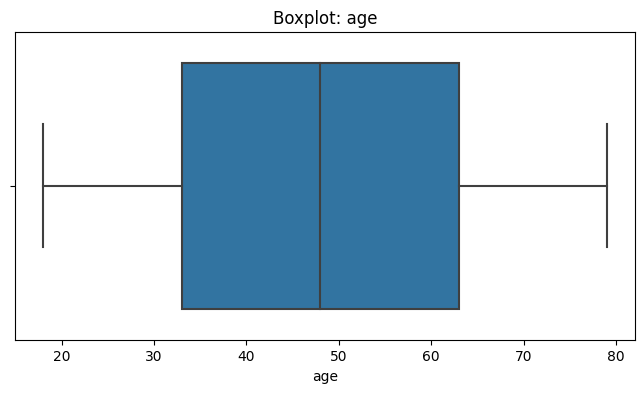

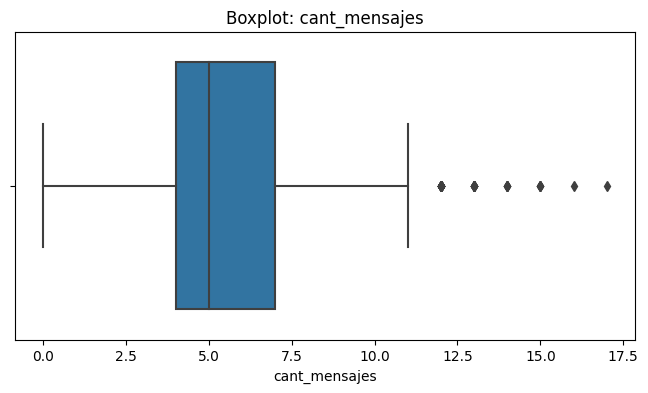

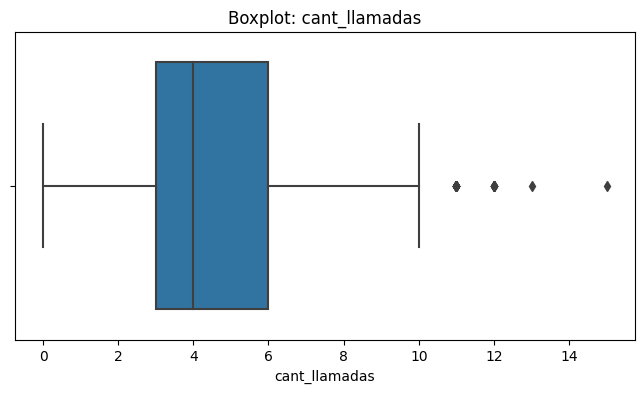

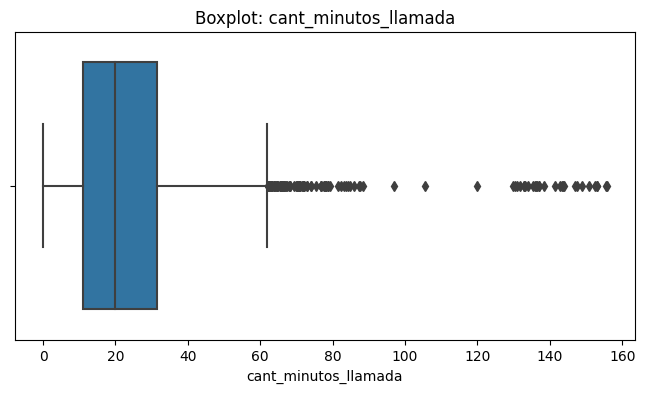

In [207]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
Age: No se identificaron valores atípicos. Las edades se encuentran dentro del rango esperado para la población analizada y presentan una distribución estable.
cant_mensajes: Se detectaron 46 outliers por encima del límite superior de 11.5 mensajes. Sin embargo, representan una proporción muy pequeña del total de usuarios (aproximadamente 1.15%), por lo que se consideran comportamientos reales de usuarios con mayor actividad y no errores de captura. Se decidió conservarlos.
cant_llamadas: Se detectaron 30 outliers por encima del límite superior de 10.5 llamadas. Estos registros representan menos del 1% de la muestra y parecen corresponder a usuarios con un uso intensivo del servicio. Se decidió mantenerlos en el análisis.
cant_minutos_llamada: Se detectaron 109 outliers por encima del límite superior de 61.86 minutos. Aunque presentan una desviación considerable respecto al comportamiento promedio, los valores máximos observados (155.69 minutos) siguen siendo plausibles para usuarios con un alto nivel de consumo. Por ello, se consideran casos válidos y se conservan para el análisis.

Conclusión: Los outliers identificados no parecen ser errores de captura ni registros inválidos. Más bien reflejan usuarios con patrones de consumo superiores al promedio, información que resulta valiosa para la segmentación y el diseño de ofertas comerciales. Por esta razón, se decidió mantener todos los outliers detectados.

In [208]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f'\n{col}')
    print(f'Limite superior: {limite_superior:.2f}')

    outliers = user_profile[user_profile[col] > limite_superior]
    print(f'Cantidad de outliers: {len(outliers)}')




cant_mensajes
Limite superior: 11.50
Cantidad de outliers: 46

cant_llamadas
Limite superior: 10.50
Cantidad de outliers: 30

cant_minutos_llamada
Limite superior: 61.86
Cantidad de outliers: 109


In [209]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

cant_mensajes: Se mantienen los outliers, ya que únicamente se identificaron 46 casos de 3,999 registros (≈1.15%). Representan usuarios con una actividad de mensajería superior al promedio y no parecen corresponder a errores de captura.
cant_llamadas: Se mantienen los outliers, ya que solamente se detectaron 30 casos de 3,999 registros (≈0.75%). Su proporción es reducida y reflejan comportamientos reales de usuarios con mayor frecuencia de llamadas.
cant_minutos_llamada: Se mantienen los outliers. Aunque se identificaron 109 casos (≈2.73%), los valores observados siguen siendo plausibles para usuarios con un consumo intensivo del servicio. Debido a su cantidad y consistencia, es poco probable que correspondan a errores de captura; más bien representan un segmento de usuarios con uso significativamente superior al promedio.

Conclusión: Los outliers detectados aportan información relevante sobre usuarios de alto consumo y no presentan evidencia de ser errores o registros inválidos, por lo que se decidió conservarlos para el análisis. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [210]:
# Crear columna grupo_uso

def clasificar_uso(fila):
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

# Verificar resultado
user_profile['grupo_uso'].value_counts()


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [211]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [212]:

# Crear columna grupo_edad

user_profile['grupo_edad'] = user_profile['age'].apply(
    lambda x: 'Joven' if x < 30
    else 'Adulto' if x < 60
    else 'Adulto Mayor'
)



In [213]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

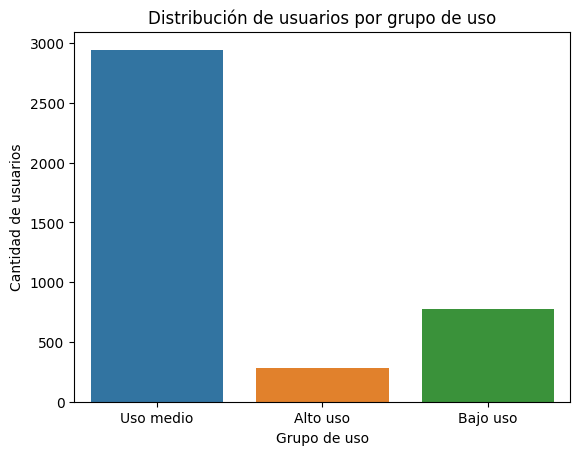

In [214]:

# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()


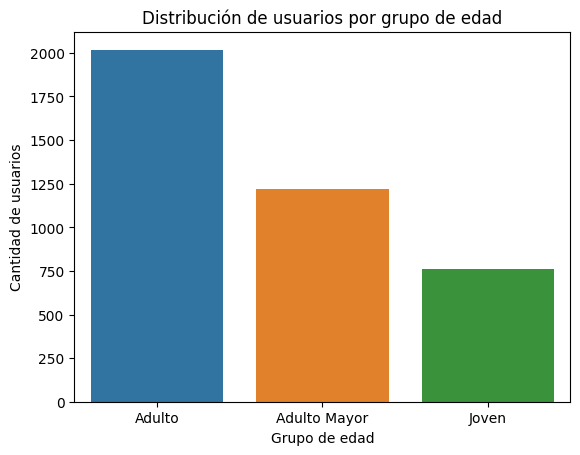

In [215]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**



⚠️ Problemas detectados en los datos

Se identificaron valores faltantes y valores centinela en variables como age y city, los cuales fueron corregidos durante el proceso de limpieza.
Se detectaron 40 registros con fechas de 2026 en reg_date, aunque los datos debían llegar únicamente hasta 2024. Además, se verificó que los valores nulos en duration y length correspondían a la naturaleza de los registros y no a errores de captura.

🔍 Segmentos por Edad

Los usuarios fueron clasificados en Jóvenes, Adultos y Adultos Mayores para facilitar el análisis de comportamiento.
La mayor parte de los usuarios se concentra en edades adultas, mientras que los adultos mayores representan una proporción menor de la base de clientes.

📊 Segmentos por Nivel de Uso

Los usuarios fueron segmentados en Bajo uso, Uso medio y Alto uso según su cantidad de llamadas y mensajes.
Se observó la existencia de usuarios con consumos significativamente superiores al promedio, lo que indica diferentes niveles de necesidad y uso del servicio.

➡️ Esto sugiere que ConnectaTel cuenta con perfiles de clientes heterogéneos, por lo que una estrategia única de planes podría no satisfacer adecuadamente las necesidades de todos los segmentos.

💡 Recomendaciones

Diseñar planes diferenciados para usuarios de alto consumo, incorporando beneficios adicionales relacionados con llamadas y mensajería.
Implementar estrategias de retención y promociones específicas para usuarios de bajo uso con el fin de incrementar su nivel de participación y permanencia.



---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`